# INF-8239 · Unidad 03 · Ejercicio 05 · Motor recomendador reproducible

Estudiante: Jose Miguel Maduro Valenzuela

Este notebook consolida LAB08 y LAB09 usando el código del paquete `src/inf8239_u03`. No contiene
lógica propia de modelos: llama a las mismas funciones que los scripts y las pruebas.

Requisito previo (MovieLens no se redistribuye en el repositorio):
```bash
uv sync
uv run python scripts/download_data.py
```
Las 12 corridas de LAB09 se generan con `scripts/lab09_hybrid.py` (ver README); aquí se reproduce una
de ellas y se resumen todas.

In [1]:
import json
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from inf8239_u03.config import MOVIELENS_DIR
from inf8239_u03.data import load_movielens
from inf8239_u03.metrics import catalog_coverage, hit_rate_at_k
from inf8239_u03.recommenders import ContentRecommender, MatrixFactorization, temporal_leave_one_out, weighted_popularity

pd.set_option("display.width", 160, "display.max_colwidth", 60)
print("Proyecto:", ROOT.name)

Proyecto: INF8239_U03


## 1. Datos, licencia y auditoría

MovieLens Latest Small (GroupLens Research, University of Minnesota), versión generada el 2018-09-26, SHA-256 del ZIP `696d65a3dfceac7c45750ad32df2c259311949efec81f0f144fdfb91ebc9e436`. Uso para investigación, sin fines comerciales, citando a Harper y Konstan (2015), doi:10.1145/2827872. `load_movielens` valida columnas, claves foráneas y rango de ratings.

In [2]:
ratings, movies = load_movielens(MOVIELENS_DIR)
audit = pd.Series({
    "usuarios": ratings["userId"].nunique(),
    "películas en catálogo": len(movies),
    "películas con rating": ratings["movieId"].nunique(),
    "ratings": len(ratings),
    "densidad": len(ratings) / (ratings["userId"].nunique() * len(movies)),
    "rating medio": ratings["rating"].mean(),
    "ratings por usuario (mín)": ratings.groupby("userId").size().min(),
    "desde": pd.to_datetime(ratings["timestamp"].min(), unit="s").date(),
    "hasta": pd.to_datetime(ratings["timestamp"].max(), unit="s").date(),
})
audit

usuarios                            610
películas en catálogo              9742
películas con rating               9724
ratings                          100836
densidad                       0.016968
rating medio                   3.501557
ratings por usuario (mín)            20
desde                        1996-03-29
hasta                        2018-09-24
dtype: object

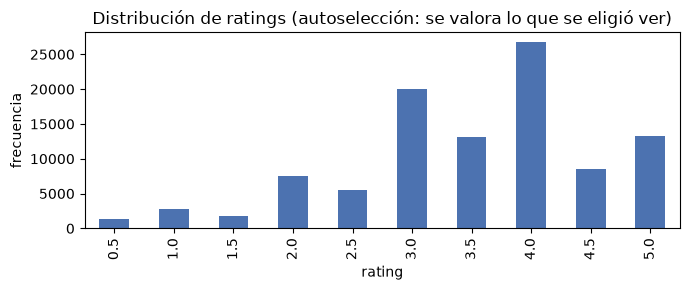

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ratings["rating"].value_counts().sort_index().plot.bar(ax=ax, color="#4c72b0")
ax.set_title("Distribución de ratings (autoselección: se valora lo que se eligió ver)")
ax.set_xlabel("rating"); ax.set_ylabel("frecuencia")
plt.tight_layout()

## 2. Baseline de popularidad suavizada (LAB08)

Promedio bayesiano con `m` = percentil 80 de conteos; una película con pocas valoraciones se acerca a la media global.

In [4]:
popular = weighted_popularity(ratings, movies)
popular[["title", "count", "mean", "weighted_score"]].head(10).round(3)

,title,count,mean,weighted_score
movieId,,,,
318,"Shawshank Redemption, The (1994)",317,4.429,4.395
858,"Godfather, The (1972)",192,4.289,4.243
2959,Fight Club (1999),218,4.273,4.233
260,Star Wars: Episode IV - A New Hope (1977),251,4.231,4.198
50,"Usual Suspects, The (1995)",204,4.238,4.197
1221,"Godfather: Part II, The (1974)",129,4.260,4.195
527,Schindler's List (1993),220,4.225,4.188
1213,Goodfellas (1990),126,4.250,4.185
750,Dr. Strangelove or: How I Learned to Stop Worrying and L...,97,4.268,4.184


## 3. Recomendación por contenido (LAB08)

TF-IDF de géneros y similitud coseno. Tres consultas de géneros distintos.

In [5]:
content = ContentRecommender().fit(movies)
for title in ["Toy Story (1995)", "Shawshank Redemption, The (1994)", "Shining, The (1980)"]:
    recs = content.recommend(title, 10)
    genres = movies.loc[movies["title"].eq(title), "genres"].iloc[0]
    ties = movies["genres"].eq(genres).sum() - 1
    assert title not in set(recs["title"])
    print(f"{title} [{genres}] · películas empatadas con score 1.0: {ties}")
    print(recs[["title", "content_score"]].to_string(index=False), end="\n\n")

Toy Story (1995) [Adventure|Animation|Children|Comedy|Fantasy] · películas empatadas con score 1.0: 12
                                                  title  content_score
                                           Turbo (2013)            1.0
                       Emperor's New Groove, The (2000)            1.0
         Adventures of Rocky and Bullwinkle, The (2000)            1.0
                                     Toy Story 2 (1999)            1.0
Asterix and the Vikings (Astérix et les Vikings) (2006)            1.0
                                            Antz (1998)            1.0
                                       Wild, The (2006)            1.0
                                 Shrek the Third (2007)            1.0
                               The Good Dinosaur (2015)            1.0
                                  Monsters, Inc. (2001)            1.0

Shawshank Redemption, The (1994) [Crime|Drama] · películas empatadas con score 1.0: 133
                           

Todas las recomendaciones tienen `content_score = 1.0`: comparten exactamente los géneros de la consulta, el orden dentro del empate es arbitrario y el modelo sobre-especializa.

## 4. Corte temporal y factorización (LAB09)

Se reserva la última valoración de cada usuario (sin usar interacciones futuras). Se reproduce la configuración seleccionada: 10 factores, 12 épocas, semilla 42.

In [6]:
train, test = temporal_leave_one_out(ratings)
start = perf_counter()
model = MatrixFactorization(factors=10, seed=42).fit(train, epochs=12)
train_seconds = perf_counter() - start
evaluable = test[test["userId"].isin(model.user_index) & test["movieId"].isin(model.item_index)]
predictions = np.array([model.predict(r.userId, r.movieId) for r in evaluable.itertuples()])
rmse = float(np.sqrt(np.mean((evaluable["rating"].to_numpy() - predictions) ** 2)))
user_mean = train.groupby("userId")["rating"].mean()
baselines = {
    "media global": float(np.sqrt(np.mean((evaluable["rating"] - train["rating"].mean()) ** 2))),
    "media de cada usuario": float(np.sqrt(np.mean((evaluable["rating"] - evaluable["userId"].map(user_mean)) ** 2))),
    "factorización (10 factores)": rmse,
}
print(f"Entrenamiento: {train_seconds:.1f} s · usuarios evaluados: {len(evaluable)} de {test['userId'].nunique()}")
print(f"Cold start de ítem (película retenida ausente del entrenamiento): {(~test['movieId'].isin(model.item_index)).sum()}")
pd.Series(baselines, name="RMSE").round(4)

Entrenamiento: 11.9 s · usuarios evaluados: 587 de 610
Cold start de ítem (película retenida ausente del entrenamiento): 23


media global                   1.1157
media de cada usuario          1.0231
factorización (10 factores)    1.0337
Name: RMSE, dtype: float64

In [7]:
collaborative = {}
for user_id in evaluable["userId"].unique():
    seen = set(train.loc[train["userId"].eq(user_id), "movieId"])
    collaborative[int(user_id)] = model.top_n(user_id, seen, 10)["movieId"].astype(int).tolist()
saved = json.loads((ROOT / "reports/lab09/metrics_f10_e12_a0.75_s42.json").read_text(encoding="utf-8"))
check = pd.DataFrame({
    "notebook": [rmse, hit_rate_at_k(collaborative, evaluable, 10), catalog_coverage(collaborative, len(model.items))],
    "script (reports/lab09)": [saved["rmse"], saved["models"]["collaborative"]["hit_rate_at_10"], saved["models"]["collaborative"]["catalog_coverage"]],
}, index=["RMSE", "HitRate@10 colaborativo", "cobertura colaborativo"])
assert np.allclose(check["notebook"], check["script (reports/lab09)"])
check.round(5)

,notebook,script (reports/lab09)
RMSE,1.03367,1.03367
HitRate@10 colaborativo,0.03407,0.03407
cobertura colaborativo,0.05515,0.05515


El notebook reproduce exactamente las métricas que el script guardó para la misma configuración y semilla.

## 5. Comparación de modelos, híbrido y Pareto (12 corridas)

Resumen de `reports/lab09/metrics_*.json`: 4 configuraciones × 3 semillas (42, 7, 123).

In [8]:
runs = [json.loads(p.read_text(encoding="utf-8")) for p in sorted((ROOT / "reports/lab09").glob("metrics_*.json"))]
models = pd.DataFrame([
    {"modelo": name, "factores": r["factors"], "alpha": r["alpha"], "semilla": r["seed"], **v}
    for r in runs for name, v in r["models"].items()
])
main = models[(models["factores"] == 20) & (models["alpha"] == 0.75)]
main.groupby("modelo")[["hit_rate_at_10", "precision_at_10", "catalog_coverage"]].mean().mul(100).round(2).rename(columns=lambda c: c + " (%)")

,hit_rate_at_10 (%),precision_at_10 (%),catalog_coverage (%)
modelo,,,
collaborative,3.52,0.35,7.01
content,0.17,0.02,7.79
hybrid,3.52,0.35,7.23
popularity,4.26,0.43,1.22


In [9]:
pareto = pd.read_csv(ROOT / "reports/lab09/pareto.csv")
pareto[["factors", "alpha", "seeds", "rmse_mean", "hit_rate_mean", "hit_rate_std", "coverage_mean", "train_seconds_mean", "model_kb", "pareto_optimal"]].round(4)

,factors,alpha,seeds,rmse_mean,hit_rate_mean,hit_rate_std,coverage_mean,train_seconds_mean,model_kb,pareto_optimal
0,10,0.75,3,1.0322,0.0403,0.0094,0.0557,13.5413,805.5469,True
1,20,0.25,3,1.0261,0.0267,0.0052,0.1015,13.6255,1611.0938,False
2,20,0.75,3,1.0261,0.0352,0.0055,0.0723,14.6613,1611.0938,False
3,40,0.75,3,1.0213,0.0386,0.0060,0.0974,16.0168,3222.1875,False


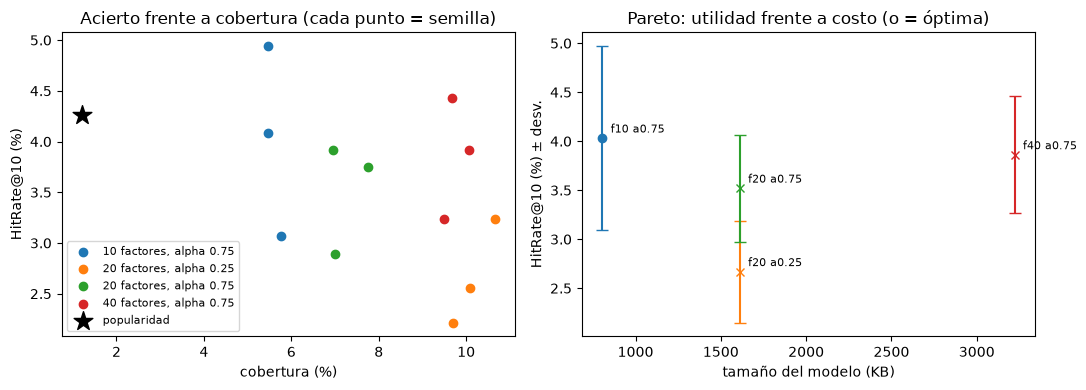

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hyb = models[models["modelo"] == "hybrid"]
for (f, a), g in hyb.groupby(["factores", "alpha"]):
    axes[0].scatter(g["catalog_coverage"] * 100, g["hit_rate_at_10"] * 100, label=f"{f} factores, alpha {a}")
pop = models[models["modelo"] == "popularity"].iloc[0]
axes[0].scatter(pop["catalog_coverage"] * 100, pop["hit_rate_at_10"] * 100, marker="*", s=200, color="black", label="popularidad")
axes[0].set_xlabel("cobertura (%)"); axes[0].set_ylabel("HitRate@10 (%)"); axes[0].set_title("Acierto frente a cobertura (cada punto = semilla)")
axes[0].legend(fontsize=8)
for _, r in pareto.iterrows():
    axes[1].errorbar(r["model_kb"], r["hit_rate_mean"] * 100, yerr=r["hit_rate_std"] * 100, fmt="o" if r["pareto_optimal"] else "x", capsize=4)
    axes[1].annotate(f"f{int(r['factors'])} a{r['alpha']}", (r["model_kb"], r["hit_rate_mean"] * 100), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xlabel("tamaño del modelo (KB)"); axes[1].set_ylabel("HitRate@10 (%) ± desv."); axes[1].set_title("Pareto: utilidad frente a costo (o = óptima)")
plt.tight_layout()

## 6. Tres perfiles y usuario frío

In [11]:
profiles = pd.read_csv(ROOT / "reports/lab09/profiles_f10_e12_a0.75_s42.csv")
assert not profiles["already_seen"].eq(True).any()
profiles[["profile", "userId", "history_size", "rank", "title", "personalized"]]

,profile,userId,history_size,rank,title,personalized
0,historial_amplio,414,2697,1,12 Angry Men (1957),True
1,historial_amplio,414,2697,2,Life Is Beautiful (La Vita è bella) (1997),True
2,historial_amplio,414,2697,3,"Philadelphia Story, The (1940)",True
3,historial_amplio,414,2697,4,Annie Hall (1977),True
4,historial_amplio,414,2697,5,My Fair Lady (1964),True
5,historial_amplio,414,2697,6,Bicycle Thieves (a.k.a. The Bicycle Thief) (a.k.a. The B...,True
6,historial_amplio,414,2697,7,Shutter Island (2010),True
7,historial_amplio,414,2697,8,Intouchables (2011),True
8,historial_amplio,414,2697,9,Psycho (1960),True
9,historial_amplio,414,2697,10,"Lives of Others, The (Das leben der Anderen) (2006)",True


In [12]:
stability = {}
for profile in ["historial_amplio", "historial_pequeno"]:
    sets = [set(pd.read_csv(ROOT / f"reports/lab09/profiles_f10_e12_a0.75_s{s}.csv").query("profile == @profile")["title"]) for s in (42, 7, 123)]
    stability[profile] = len(set.intersection(*sets))
pd.Series(stability, name="títulos presentes en las 3 semillas (de 10)")

historial_amplio     5
historial_pequeno    0
Name: títulos presentes en las 3 semillas (de 10), dtype: int64

## 7. Decisión

Configuración seleccionada: **10 factores, 12 épocas, alpha 0.75**. Es la única óptima de Pareto en HitRate@10 frente a tiempo y tamaño, y alpha 0.75 supera a 0.25 en las tres semillas. Límites: ninguna configuración personalizada supera al baseline de popularidad en aciertos; las diferencias entre configuraciones están dentro de la variación entre semillas; la configuración elegida es la de menor cobertura; el usuario con poco historial recibe listas inestables y el usuario nuevo recibe un fallback no personalizado. Análisis completo en `reports/lab09/`.